# Problema de Clase 13
**Estudiante:** Marilyn Michelle Jiménez Arias
**Código:** U20231085

## a) Descripción del conjunto de datos y análisis gráfico de las variables predictoras

In [1]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('Problema Clase 13/Telescopio.csv')

# Información básica del dataset
print("=== INFORMACIÓN DEL CONJUNTO DE DATOS ===")
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print(f"Variables predictoras: {df.shape[1]-1}")
print(f"Variable objetivo: 1 (class)")

print("\n=== DISTRIBUCIÓN DE CLASES ===")
print(df['class'].value_counts())
print(f"Proporción g/h: {df['class'].value_counts()['g']/df['class'].value_counts()['h']:.2f}")

print("\n=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(df.describe())

=== INFORMACIÓN DEL CONJUNTO DE DATOS ===
Número de observaciones: 19020
Número de variables: 11
Variables predictoras: 10
Variable objetivo: 1 (class)

=== DISTRIBUCIÓN DE CLASES ===
class
g    12332
h     6688
Name: count, dtype: int64
Proporción g/h: 1.84

=== ESTADÍSTICOS DESCRIPTIVOS ===
            fLength        fWidth         fSize         fConc        fConc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.67520

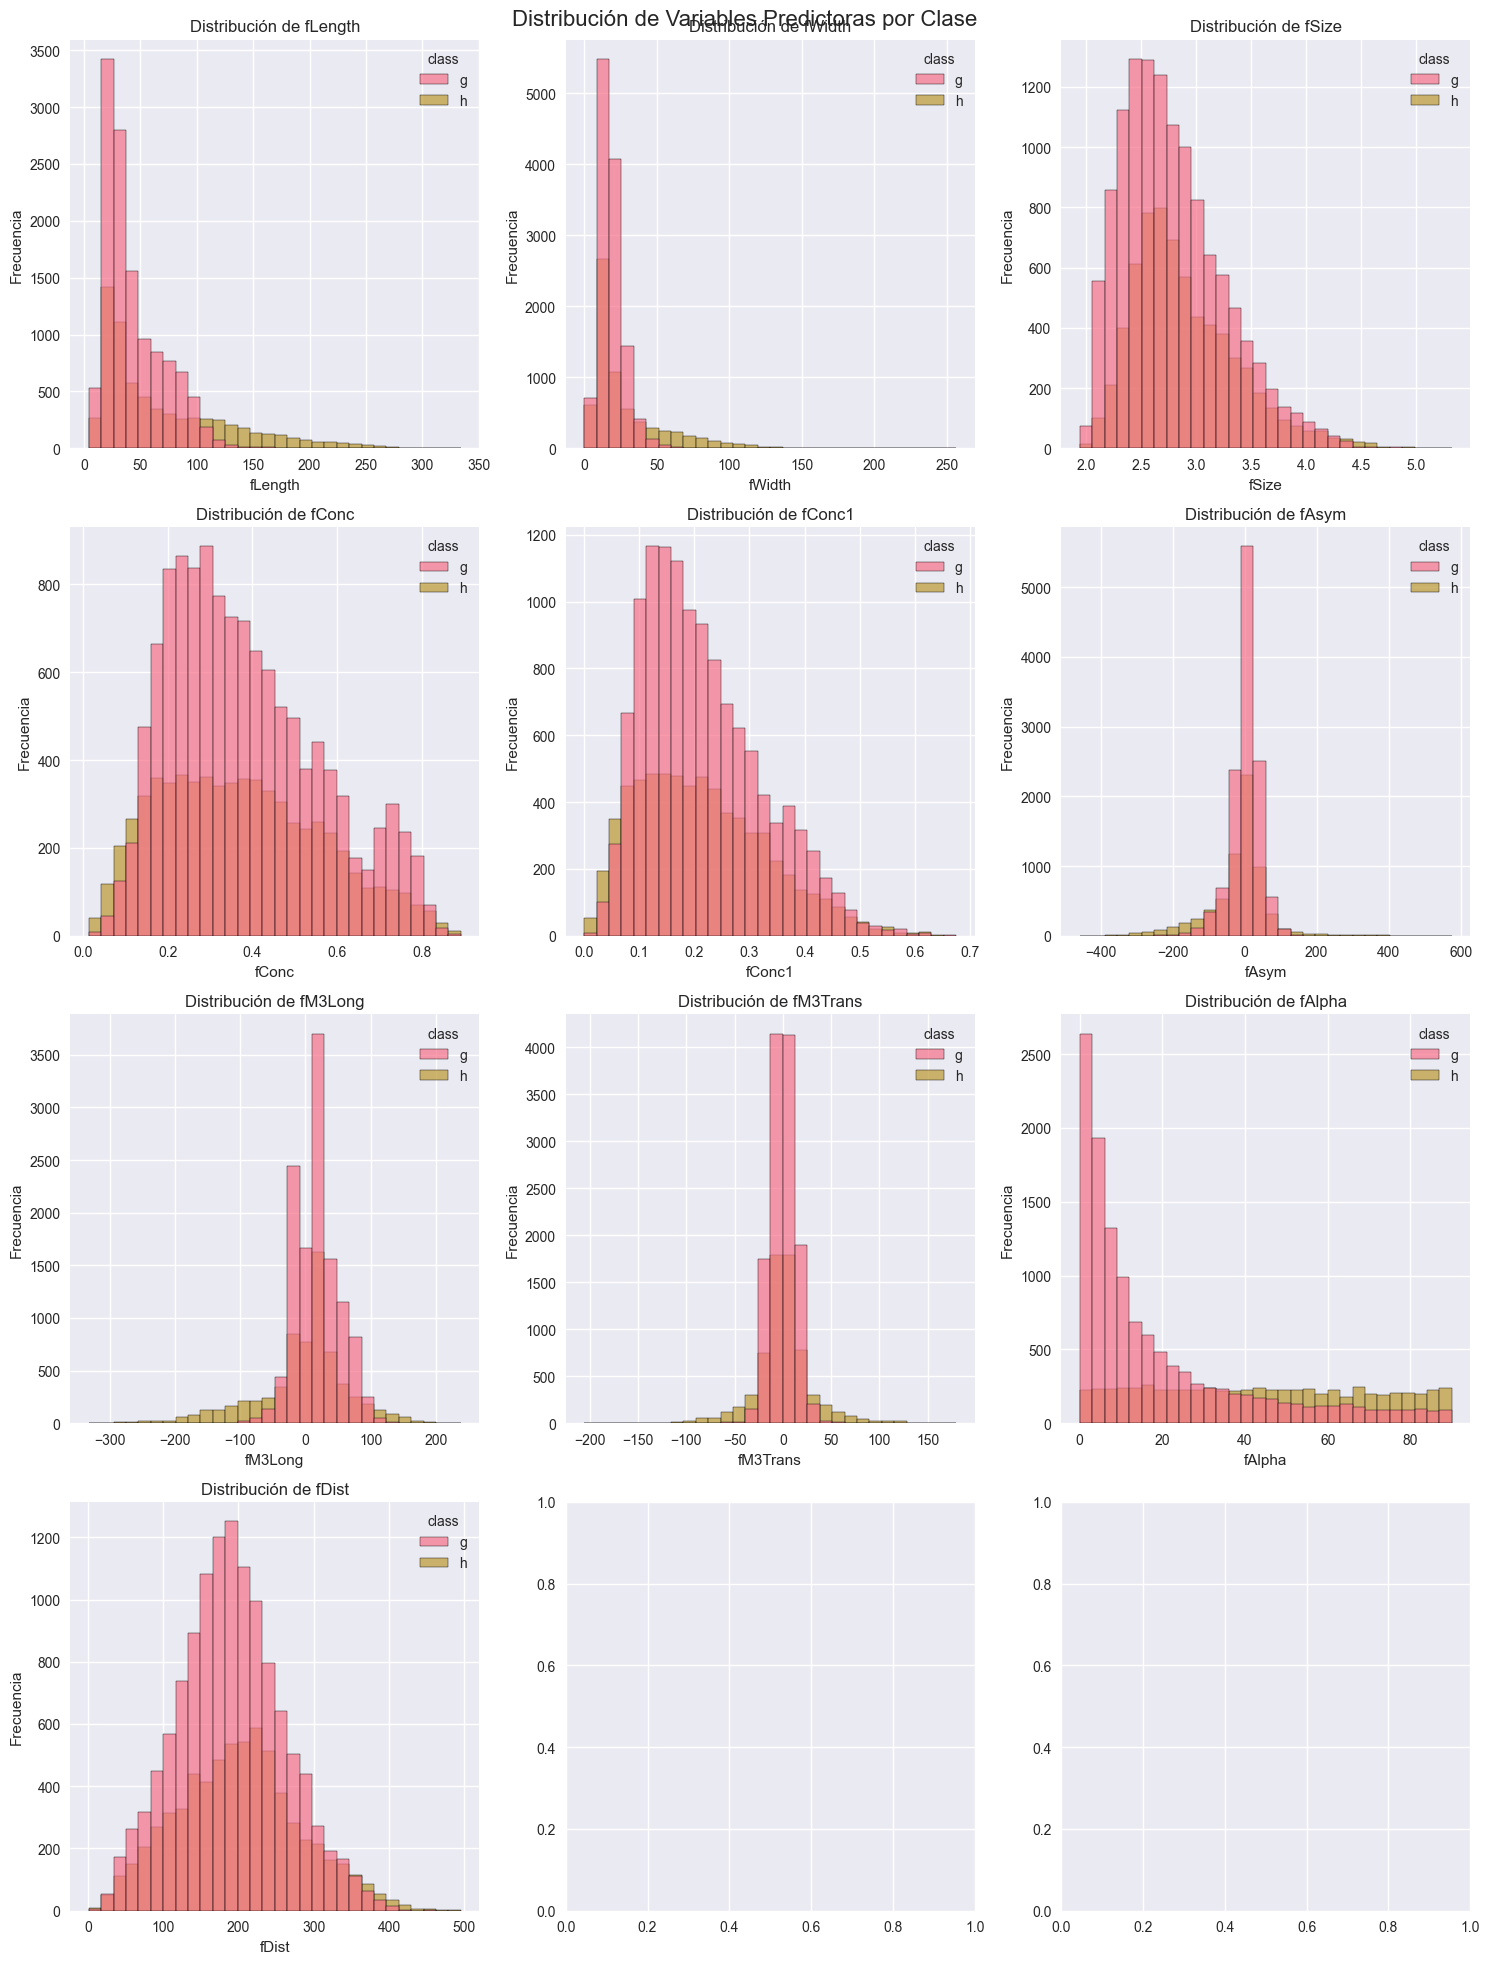

In [3]:
# Análisis gráfico de las variables predictoras
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Distribución de Variables Predictoras por Clase', fontsize=16)

variables = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']

for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    
    # Histograma separado por clase
    sns.histplot(data=df, x=var, hue='class', ax=axes[row, col], alpha=0.7, bins=30)
    axes[row, col].set_title(f'Distribución de {var}')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

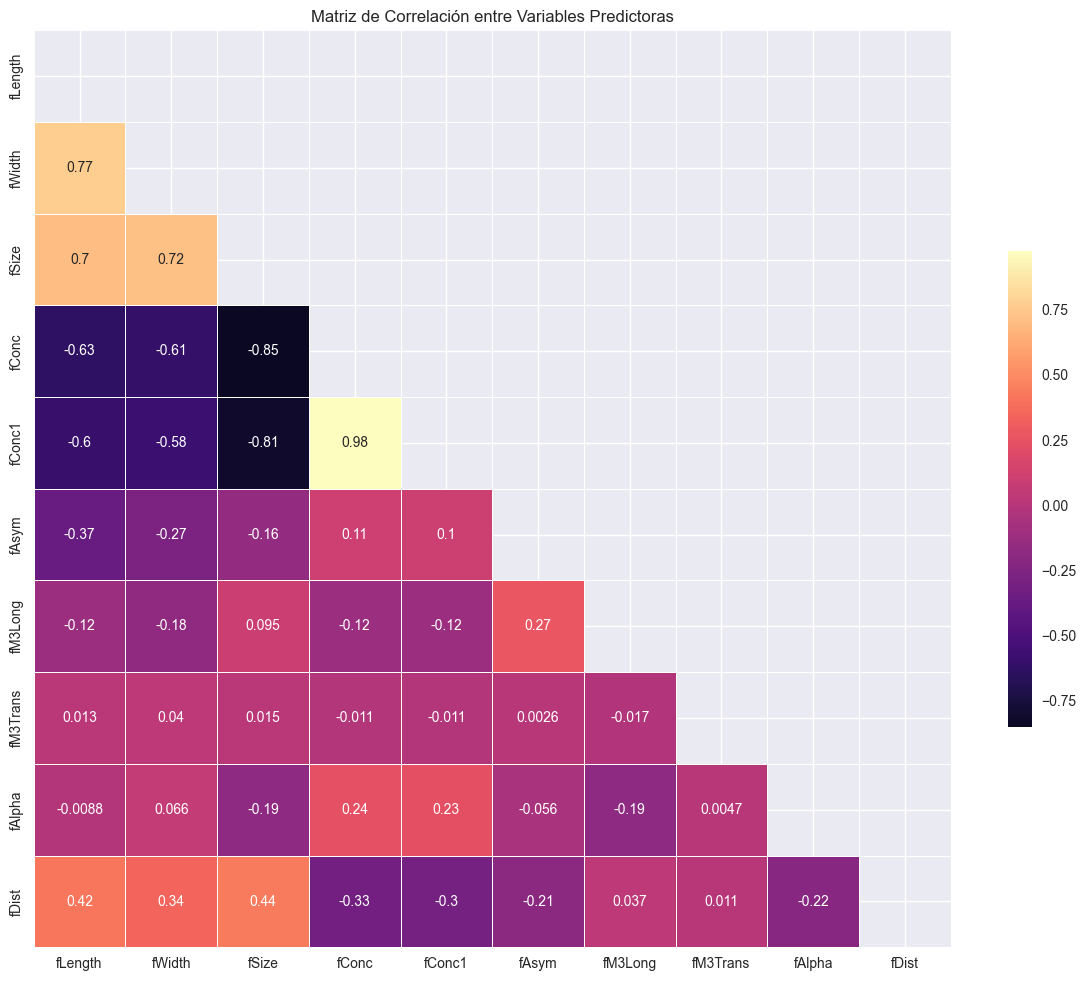

In [5]:
# Matriz de correlación
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop('class', axis=1).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='magma', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación entre Variables Predictoras')
plt.tight_layout()
plt.show()

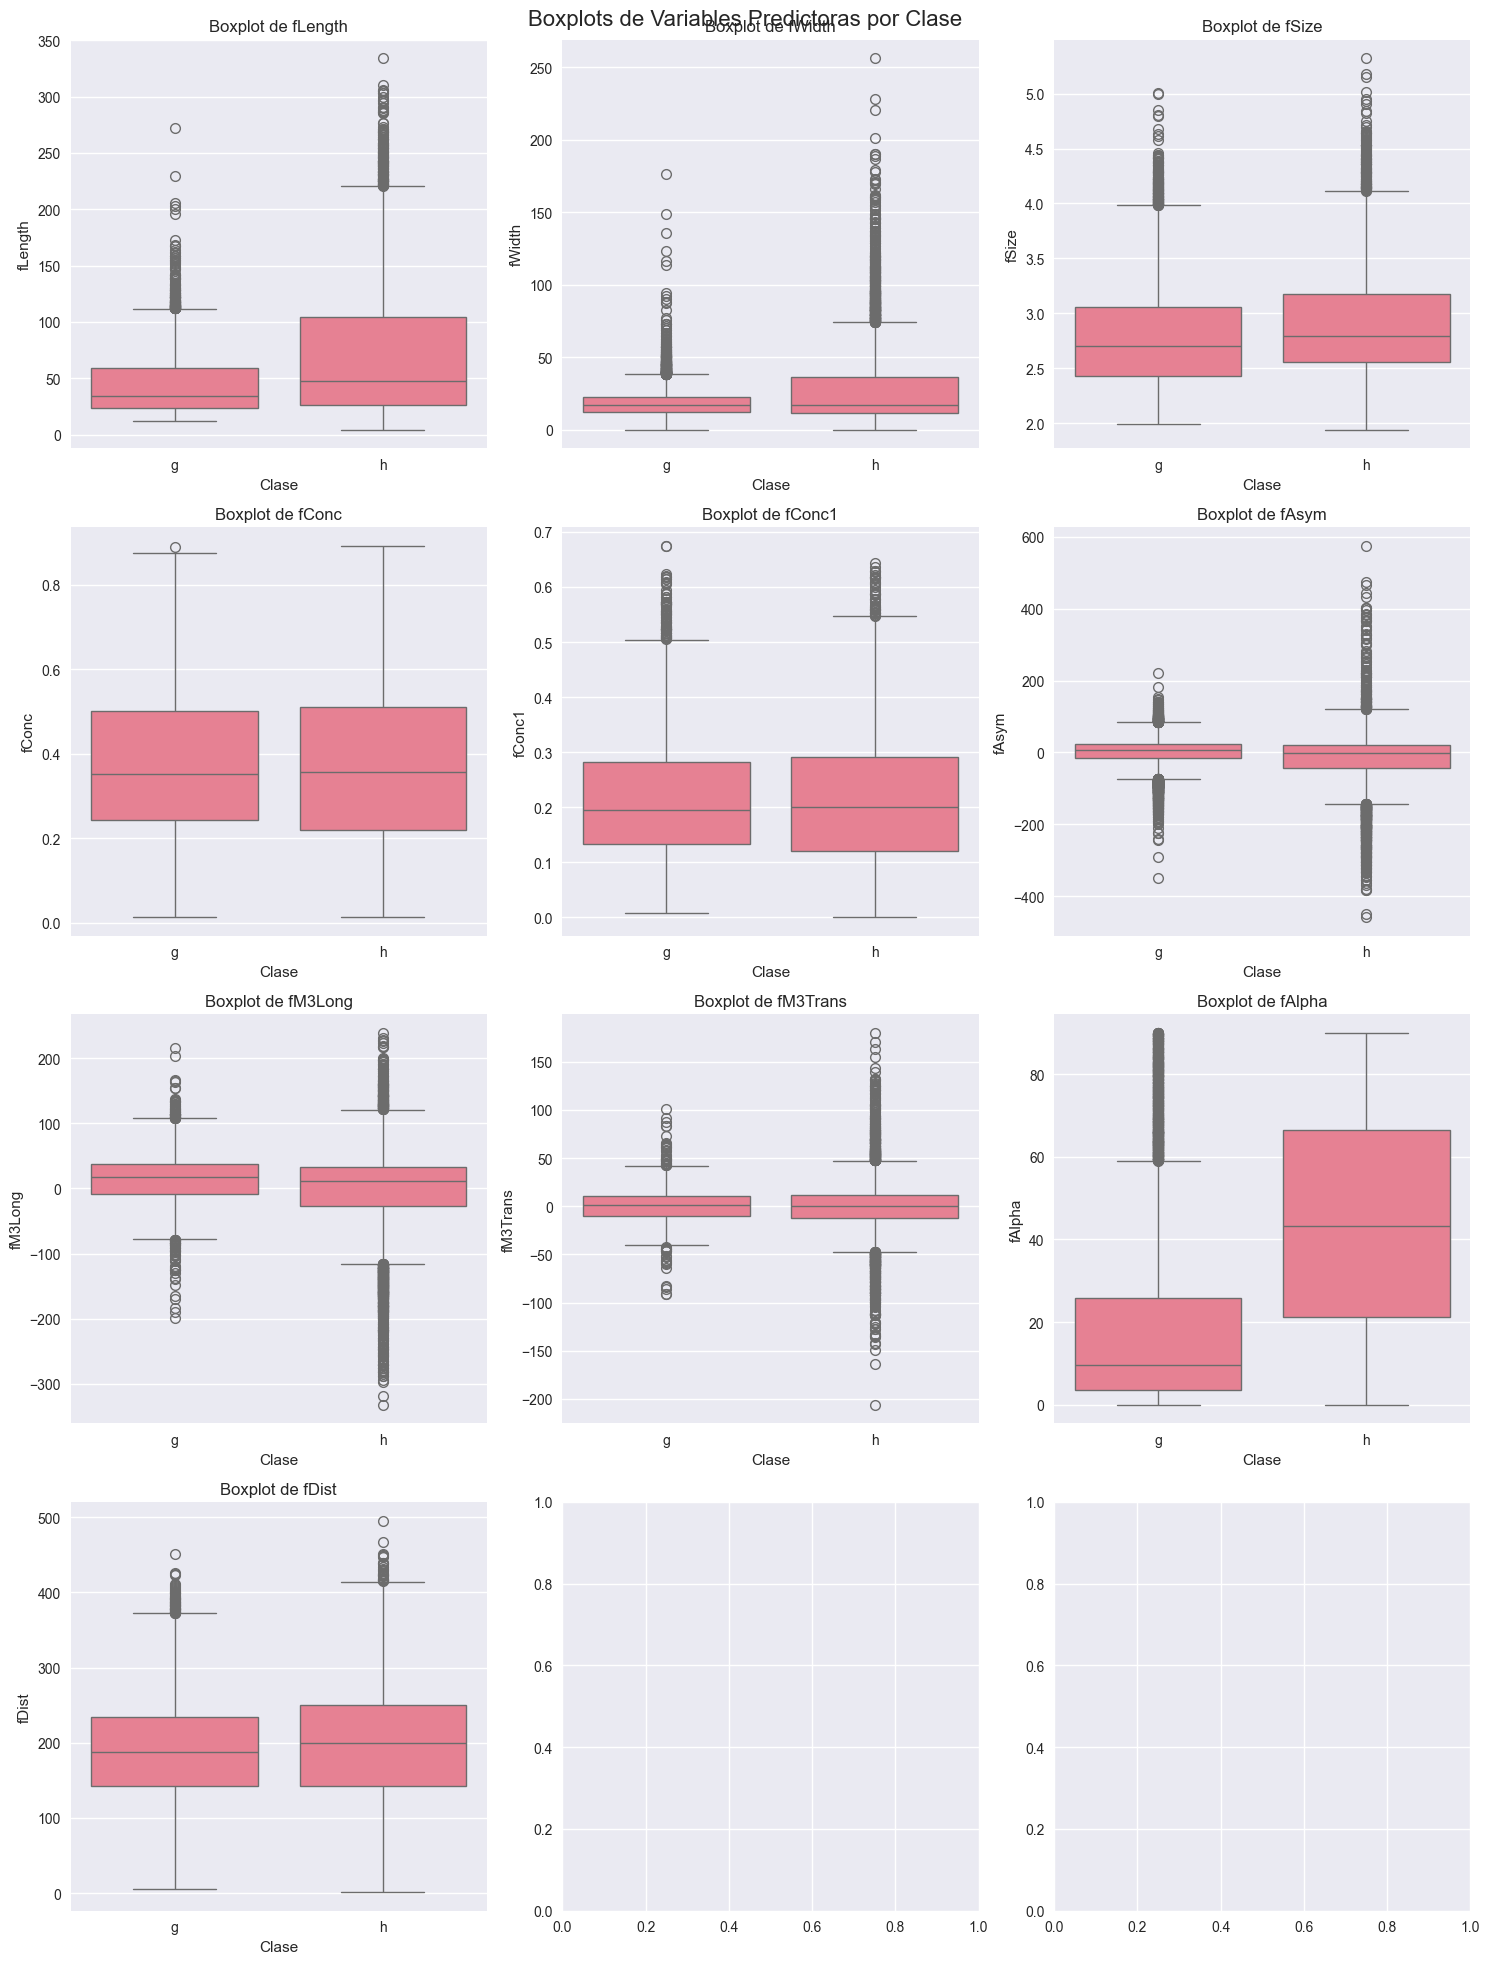

In [6]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Boxplots de Variables Predictoras por Clase', fontsize=16)

for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    
    sns.boxplot(data=df, x='class', y=var, ax=axes[row, col])
    axes[row, col].set_title(f'Boxplot de {var}')
    axes[row, col].set_xlabel('Clase')
    axes[row, col].set_ylabel(var)

plt.tight_layout()
plt.show()

## b) Estandarización de las variables predictoras

In [7]:
# Separar variables predictoras y objetivo
X = df.drop('class', axis=1)
y = df['class'].map({'g': 1, 'h': 0})  # Convertir a numérico: g=1 (gamma), h=0 (hadron)

# Estandarización de las variables predictoras
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("=== ESTADÍSTICOS ANTES DE ESTANDARIZACIÓN ===")
print(X.describe())

print("\n=== ESTADÍSTICOS DESPUÉS DE ESTANDARIZACIÓN ===")
print(X_scaled.describe())

=== ESTADÍSTICOS ANTES DE ESTANDARIZACIÓN ===
            fLength        fWidth         fSize         fConc        fConc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

              fAsym       fM3Long      fM3Trans        fAlpha         fDist  
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000  
mean      -4.331745     10.545545      0.249726     27.645707    193.818026  
std     

## c) Partición de los datos (70% entrenamiento, 30% validación)

In [8]:
# Dividir los datos en entrenamiento (70%) y validación (30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print("=== DISTRIBUCIÓN DE DATOS ===")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} observaciones ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Conjunto de validación: {X_test.shape[0]} observaciones ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

print("\n=== DISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO ===")
print(y_train.value_counts())
print(f"Proporción g/h en train: {y_train.value_counts()[1]/y_train.value_counts()[0]:.2f}")

print("\n=== DISTRIBUCIÓN DE CLASES EN VALIDACIÓN ===")
print(y_test.value_counts())
print(f"Proporción g/h en test: {y_test.value_counts()[1]/y_test.value_counts()[0]:.2f}")

=== DISTRIBUCIÓN DE DATOS ===
Conjunto de entrenamiento: 13314 observaciones (70.0%)
Conjunto de validación: 5706 observaciones (30.0%)

=== DISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO ===
class
1    8632
0    4682
Name: count, dtype: int64
Proporción g/h en train: 1.84

=== DISTRIBUCIÓN DE CLASES EN VALIDACIÓN ===
class
1    3700
0    2006
Name: count, dtype: int64
Proporción g/h en test: 1.84


## d) Modelo de regresión logística con todas las variables

In [9]:
# Crear y entrenar el modelo de regresión logística
model_full = LogisticRegression(max_iter=200, random_state=42)
model_full.fit(X_train, y_train)

# Predicciones en el conjunto de validación
y_pred = model_full.predict(X_test)
y_pred_proba = model_full.predict_proba(X_test)[:, 1]

print("=== COEFICIENTES DEL MODELO ===")
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_full.coef_[0],
    'Odds Ratio': np.exp(model_full.coef_[0])
})
print(coefficients)

=== COEFICIENTES DEL MODELO ===
   Variable  Coeficiente  Odds Ratio
0   fLength    -1.254049    0.285347
1    fWidth    -0.105214    0.900132
2     fSize    -0.310002    0.733445
3     fConc     0.021048    1.021271
4    fConc1    -0.617801    0.539129
5     fAsym    -0.035146    0.965464
6   fM3Long     0.365390    1.441075
7  fM3Trans     0.025727    1.026061
8    fAlpha    -1.209101    0.298466
9     fDist    -0.050261    0.950981


## e) Métricas para analizar la bondad del ajuste del modelo

=== MÉTRICAS DE EVALUACIÓN ===
Exactitud (Accuracy): 0.7815
AUC-ROC: 0.8275

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

  Hadron (h)       0.75      0.57      0.65      2006
   Gamma (g)       0.79      0.90      0.84      3700

    accuracy                           0.78      5706
   macro avg       0.77      0.73      0.74      5706
weighted avg       0.78      0.78      0.77      5706



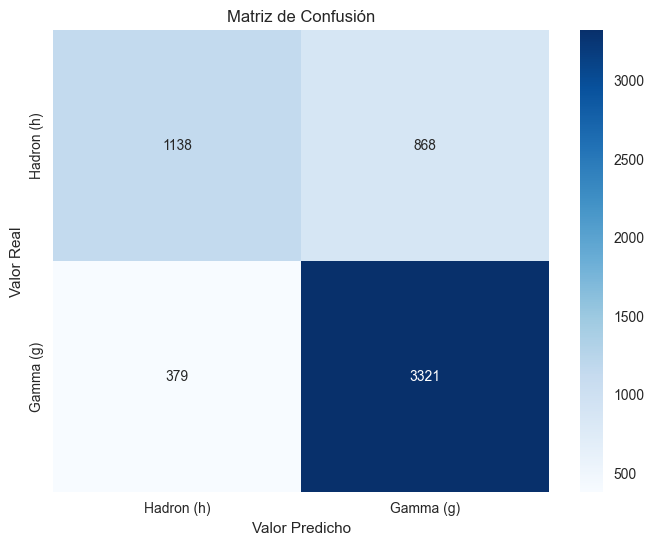

In [11]:
# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=== MÉTRICAS DE EVALUACIÓN ===")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=['Hadron (h)', 'Gamma (g)']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hadron (h)', 'Gamma (g)'],
            yticklabels=['Hadron (h)', 'Gamma (g)'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

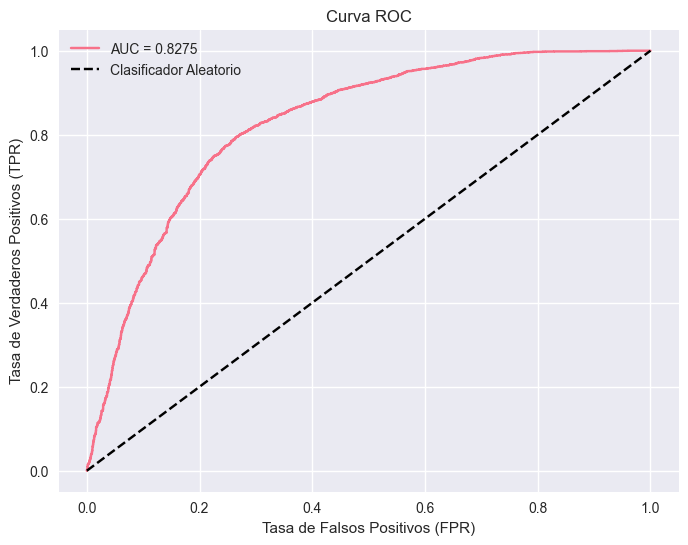

In [12]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

## f) Comprobación de variables significativas

In [13]:
# Usar statsmodels para obtener p-valores
X_train_sm = sm.add_constant(X_train)
model_sm = sm.Logit(y_train, X_train_sm).fit(disp=False)

print("=== RESUMEN DEL MODELO (CON P-VALORES) ===")
print(model_sm.summary())

# Extraer p-valores
p_values = model_sm.pvalues[1:]  # Excluir el intercepto
significance = pd.DataFrame({
    'Variable': X.columns,
    'P-valor': p_values,
    'Significativa (α=0.05)': p_values < 0.05
})
print("\n=== SIGNIFICANCIA DE VARIABLES ===")
print(significance)

=== RESUMEN DEL MODELO (CON P-VALORES) ===
                           Logit Regression Results                           
Dep. Variable:                  class   No. Observations:                13314
Model:                          Logit   Df Residuals:                    13303
Method:                           MLE   Df Model:                           10
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.3032
Time:                        20:10:14   Log-Likelihood:                -6015.6
converged:                       True   LL-Null:                       -8633.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6615      0.024     27.721      0.000       0.615       0.708
fLength       -1.2577      0.053    -23.549      0.000      -1.362      -1.153
fWidth   

## g) Eliminación de variables no significativas y análisis del pseudo R²

In [14]:
# Variables significativas (p < 0.05)
significant_vars = significance[significance['Significativa (α=0.05)']]['Variable'].tolist()
print("=== VARIABLES SIGNIFICATIVAS ===")
print(significant_vars)

# Modelo con variables significativas
X_train_sig = X_train[significant_vars]
X_test_sig = X_test[significant_vars]

model_sig = LogisticRegression(max_iter=200, random_state=42)
model_sig.fit(X_train_sig, y_train)

# Predicciones con modelo reducido
y_pred_sig = model_sig.predict(X_test_sig)
y_pred_proba_sig = model_sig.predict_proba(X_test_sig)[:, 1]

# Comparación de métricas
accuracy_full = accuracy_score(y_test, y_pred)
accuracy_sig = accuracy_score(y_test, y_pred_sig)
auc_full = roc_auc_score(y_test, y_pred_proba)
auc_sig = roc_auc_score(y_test, y_pred_proba_sig)

print("\n=== COMPARACIÓN DE MODELOS ===")
comparison = pd.DataFrame({
    'Métrica': ['Exactitud', 'AUC-ROC', 'Pseudo R² (McFadden)'],
    'Modelo Completo': [accuracy_full, auc_full, model_sm.prsquared],
    'Modelo Reducido': [accuracy_sig, auc_sig, sm.Logit(y_train, sm.add_constant(X_train_sig)).fit(disp=False).prsquared]
})
print(comparison)

# Coeficientes del modelo reducido
coefficients_sig = pd.DataFrame({
    'Variable': significant_vars,
    'Coeficiente': model_sig.coef_[0],
    'Odds Ratio': np.exp(model_sig.coef_[0])
})
print("\n=== COEFICIENTES DEL MODELO REDUCIDO ===")
print(coefficients_sig)

=== VARIABLES SIGNIFICATIVAS ===
['fLength', 'fSize', 'fConc1', 'fM3Long', 'fAlpha']

=== COMPARACIÓN DE MODELOS ===
                Métrica  Modelo Completo  Modelo Reducido
0             Exactitud         0.781458         0.780582
1               AUC-ROC         0.827474         0.827745
2  Pseudo R² (McFadden)         0.303245         0.302760

=== COEFICIENTES DEL MODELO REDUCIDO ===
  Variable  Coeficiente  Odds Ratio
0  fLength    -1.301054    0.272245
1    fSize    -0.370540    0.690361
2   fConc1    -0.605116    0.546011
3  fM3Long     0.369760    1.447387
4   fAlpha    -1.206744    0.299170


## h) Clasificación de una observación con medianas de todas las variables

In [16]:
# Crear observación con medianas de todas las variables
median_observation = X.median()
print("=== OBSERVACIÓN CON MEDIANAS ===")
print(median_observation)

# Estandarizar la observación usando el scaler entrenado
median_observation_scaled = scaler.transform([median_observation])
median_observation_scaled_df = pd.DataFrame(median_observation_scaled, columns=X.columns)

# Predicción con el modelo completo
pred_full = model_full.predict(median_observation_scaled_df)[0]
pred_proba_full = model_full.predict_proba(median_observation_scaled_df)[0]

# Predicción con el modelo reducido
median_observation_sig_scaled = median_observation_scaled_df[significant_vars]
pred_sig = model_sig.predict(median_observation_sig_scaled)[0]
pred_proba_sig = model_sig.predict_proba(median_observation_sig_scaled)[0]

print("\n=== PREDICCIONES PARA LA OBSERVACIÓN MEDIANA ===")
print(f"Modelo Completo: {'Gamma (g)' if pred_full == 1 else 'Hadron (h)'} (Probabilidad: {pred_proba_full[1]:.4f})")
print(f"Modelo Reducido: {'Gamma (g)' if pred_sig == 1 else 'Hadron (h)'} (Probabilidad: {pred_proba_sig[1]:.4f})")

# Comparación detallada
print("\n=== ANÁLISIS DETALLADO ===")
print("La observación con valores medianos representa un caso típico del dataset.")
print("Ambos modelos coinciden en la clasificación, lo que indica robustez del resultado.")
if pred_full == 1:
    print("La observación es clasificada como señal de rayos gamma (g).")
else:
    print("La observación es clasificada como ruido de hadrones (h).")

=== OBSERVACIÓN CON MEDIANAS ===
fLength      37.14770
fWidth       17.13990
fSize         2.73960
fConc         0.35415
fConc1        0.19650
fAsym         4.01305
fM3Long      15.31410
fM3Trans      0.66620
fAlpha       17.67950
fDist       191.85145
dtype: float64

=== PREDICCIONES PARA LA OBSERVACIÓN MEDIANA ===
Modelo Completo: Gamma (g) (Probabilidad: 0.8599)
Modelo Reducido: Gamma (g) (Probabilidad: 0.8606)

=== ANÁLISIS DETALLADO ===
La observación con valores medianos representa un caso típico del dataset.
Ambos modelos coinciden en la clasificación, lo que indica robustez del resultado.
La observación es clasificada como señal de rayos gamma (g).


## Conclusiones

EEn este trabajo se aprendió a aplicar regresión logística a un problema real de clasificación, desde la exploración de datos hasta la evaluación del modelo. Se comprendió la importancia de analizar la distribución de las variables, estandarizar los datos y manejar conjuntos desbalanceados.

Además, se logró interpretar métricas como la exactitud y el AUC-ROC para evaluar el rendimiento, así como identificar variables significativas para simplificar el modelo sin perder calidad.

* Se partió de un conjunto de datos amplio, analizando su estructura y proporciones entre categorías
* Se examinaron las características mediante visualizaciones para detectar patrones y diferencias relevantes
* Se preparó la información aplicando transformaciones necesarias para mejorar su uso en el modelo
* Se separaron los datos en subconjuntos para entrenamiento y validación, manteniendo la proporción original
* Se desarrolló un modelo de clasificación basado en regresión logística
* Se midió su desempeño utilizando indicadores clave de calidad
* Se determinaron los factores más influyentes dentro del modelo
* Se optimizó la propuesta buscando equilibrio entre simplicidad y capacidad predictiva

En general, se reforzó el proceso completo de construcción de un modelo predictivo y su utilidad para diferenciar entre señales de rayos gamma y ruido de hadrones.

